# Exploratory Data Analysis

Three datasets:
1. **News Category Dataset** (HuffPost, ~210k articles) — Kaggle: `rmisra/news-category-dataset`
2. **Million Headlines** (ABC Australia, ~1M headlines) — Kaggle: `therohk/million-headlines`
3. **EMDAT** — Global disaster events database (local CSV)

## Setup

Run this cell first. It installs `kagglehub` if needed and imports all libraries.

In [12]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for pkg in ["kagglehub", "pandas", "matplotlib", "seaborn", "openpyxl"]:
    install(pkg)

import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
print("All libraries loaded.")

All libraries loaded.


---
## Dataset 1: News Category Dataset (HuffPost)

Filtered to 8 categories: U.S. NEWS, POLITICS, WEIRD NEWS, ENVIRONMENT, EDUCATION, SCIENCE, MEDIA, IMPACT  
Date range: 2012–2021 | Columns kept: `headline`, `publish_date` (YYYYMMDD integer)

In [ ]:
# Download dataset — first run may take a minute
path1 = kagglehub.dataset_download("rmisra/news-category-dataset")
print("Downloaded to:", path1)

jsonl_file = [f for f in os.listdir(path1) if f.endswith(".json")][0]
with open(os.path.join(path1, jsonl_file), "r", encoding="utf-8") as f:
    news_raw = pd.DataFrame([json.loads(line) for line in f])

print(f"Raw shape: {news_raw.shape}")
news_raw.head(3)

In [ ]:
KEEP_CATS = ["U.S. NEWS", "POLITICS", "WEIRD NEWS", "ENVIRONMENT",
             "EDUCATION", "SCIENCE", "MEDIA", "IMPACT"]

# Show category counts before dropping the column
print("Articles per kept category (before date filter):")
print(news_raw[news_raw["category"].isin(KEEP_CATS)]["category"].value_counts())

# Filter to selected categories, keep only headline + date
news = (news_raw[news_raw["category"].isin(KEEP_CATS)]
        [["headline", "date"]]
        .copy())

# Parse date, filter to 2012–2021
news["date"] = pd.to_datetime(news["date"], errors="coerce")
news = news[(news["date"].dt.year >= 2012) & (news["date"].dt.year <= 2021)]

# Rename and convert to YYYYMMDD integer (same format as ABC Australia, no dashes)
news = news.rename(columns={"date": "publish_date"})
news["publish_date"] = news["publish_date"].dt.strftime("%Y%m%d").astype(int)

# Drop duplicates and reset index
news = news.drop_duplicates().reset_index(drop=True)

print(f"\nShape after filtering: {news.shape}")
print(f"Date range: {news['publish_date'].min()} → {news['publish_date'].max()}")
news.head(5)

In [ ]:
print("=== Data Types & Non-Null Counts ===")
news.info()

print("\n=== Missing Values ===")
print(news.isnull().sum())

print("\n=== Duplicate Rows ===")
print(news.duplicated().sum())

In [ ]:
# Convert publish_date back to datetime just for plotting
news_plot = news.copy()
news_plot["date_dt"] = pd.to_datetime(news_plot["publish_date"].astype(str), format="%Y%m%d")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Articles per year
news_plot["date_dt"].dt.year.value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue"
)
axes[0].set_title("HuffPost Articles per Year (2012–2021)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")

# Articles per month (seasonality)
news_plot["date_dt"].dt.month.value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="steelblue"
)
axes[1].set_title("Articles per Month (seasonality)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [ ]:
news["headline_len"] = news["headline"].str.split().str.len()
print(news["headline_len"].describe())

news["headline_len"].plot(kind="hist", bins=40, color="steelblue", edgecolor="white")
plt.title("Headline Word Count Distribution (HuffPost, filtered)")
plt.xlabel("Words in headline")
plt.ylabel("Frequency")
plt.show()

---
## Dataset 2: Million Headlines (ABC Australia)

Filtered to 2012–2021 | Columns: `publish_date` (datetime), `headline_text`

In [17]:
# Download dataset
path2 = kagglehub.dataset_download("therohk/million-headlines")
print("Downloaded to:", path2)

csv_file = [f for f in os.listdir(path2) if f.endswith(".csv")][0]
headlines = pd.read_csv(os.path.join(path2, csv_file))

print(f"Shape: {headlines.shape}")
headlines.head(3)

Downloaded to: C:\Users\nicot\.cache\kagglehub\datasets\therohk\million-headlines\versions\5
Shape: (1244184, 2)


,publish_date,headline_text
0,20030219,aba decides against community broadcasting lic...
1,20030219,act fire witnesses must be aware of defamation
2,20030219,a g calls for infrastructure protection summit


In [ ]:
print("=== Missing Values (raw) ===")
print(headlines.isnull().sum())

print(f"\n=== Duplicates (raw): {headlines.duplicated().sum()} ===")

# Parse date (format: YYYYMMDD integer)
headlines["publish_date"] = pd.to_datetime(
    headlines["publish_date"].astype(str), format="%Y%m%d", errors="coerce"
)

# Filter to 2012–2021
headlines = (headlines[
    (headlines["publish_date"].dt.year >= 2012) &
    (headlines["publish_date"].dt.year <= 2021)
].drop_duplicates().reset_index(drop=True))

print(f"\nShape after filtering to 2012–2021: {headlines.shape}")
print(f"Date range: {headlines['publish_date'].min()} → {headlines['publish_date'].max()}")
headlines.head(3)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Headlines per year
headlines["publish_date"].dt.year.value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="teal"
)
axes[0].set_title("ABC Headlines per Year (2012–2021)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")

# Headline word count distribution
headlines["word_count"] = headlines["headline_text"].str.split().str.len()
headlines["word_count"].plot(kind="hist", bins=30, ax=axes[1], color="teal", edgecolor="white")
axes[1].set_title("Headline Word Count Distribution")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(headlines["word_count"].describe())

---
## Dataset 3: EMDAT — Natural Disaster Events

Filtered to **Natural disasters only** (Technological removed).  
Local file: `data/EMDAT.csv` (semicolon-delimited)

In [ ]:
import os

# Set working directory to the project root
notebook_dir = os.path.dirname(os.path.abspath("eda.ipynb"))
os.chdir(notebook_dir)

emdat_path = os.path.join(notebook_dir, "data", "EMDAT.csv")
emdat_raw = pd.read_csv(emdat_path, sep=";", encoding="latin-1", low_memory=False)
print(f"Raw shape: {emdat_raw.shape}")
print("Disaster Group counts:")
print(emdat_raw["Disaster Group"].value_counts())

# Keep only Natural disasters
emdat = emdat_raw[emdat_raw["Disaster Group"] == "Natural"].copy().reset_index(drop=True)
print(f"\nShape after filtering to Natural only: {emdat.shape}")
emdat.head(3)

In [21]:
print("=== Columns ===")
print(list(emdat.columns))

print("\n=== Data Types ===")
emdat.info()

print("\n=== Missing Values (%) ===")
missing = (emdat.isnull().sum() / len(emdat) * 100).sort_values(ascending=False)
print(missing[missing > 0].round(1))

=== Columns ===
['DisNo.', 'Historic', 'Classification Key', 'Disaster Group', 'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype', 'External IDs', 'Event Name', 'ISO', 'Country', 'Subregion', 'Region', 'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal', 'Declaration', "AID Contribution ('000 US$)", 'Magnitude', 'Magnitude Scale', 'Latitude', 'Longitude', 'River Basin', 'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day', 'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected', "Reconstruction Costs ('000 US$)", "Reconstruction Costs, Adjusted ('000 US$)", "Insured Damage ('000 US$)", "Insured Damage, Adjusted ('000 US$)", "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)", 'CPI', 'Admin Units', 'GADM Admin Units', 'Entry Date', 'Last Update']

=== Data Types ===
<class 'pandas.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 47 columns):
 #   Column                                  

In [22]:
# Fix numeric columns that may have commas as decimal separators
for col in ["Total Deaths", "No. Affected", "Total Affected",
            "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)"]:
    if col in emdat.columns:
        emdat[col] = (
            emdat[col].astype(str)
            .str.replace(",", ".", regex=False)
            .str.replace(" ", "", regex=False)
            .pipe(pd.to_numeric, errors="coerce")
        )

print(emdat[["Start Year", "Total Deaths", "Total Affected",
             "Total Damage ('000 US$)"]].describe())

        Start Year  Total Deaths  Total Affected  Total Damage ('000 US$)
count   331.000000    254.000000    1.920000e+02             2.730000e+02
mean   2016.700906     15.350394    4.612040e+05             2.664681e+06
std       2.967189     28.228305    6.134154e+06             8.711129e+06
min    2012.000000      1.000000    1.000000e+00             2.000000e+03
25%    2014.000000      2.000000    1.090000e+02             1.750000e+05
50%    2016.000000      6.000000    4.440000e+02             9.500000e+05
75%    2019.000000     15.000000    3.262500e+03             2.000000e+06
max    2021.000000    235.000000    8.500001e+07             9.500000e+07


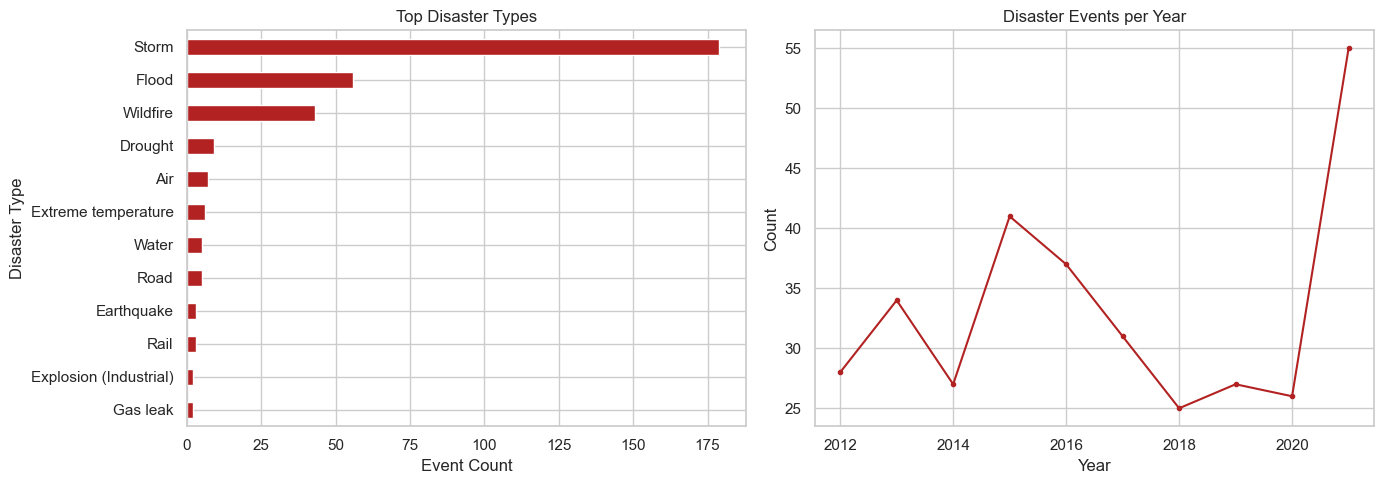

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Disaster type counts
emdat["Disaster Type"].value_counts().head(12).plot(
    kind="barh", ax=axes[0], color="firebrick"
)
axes[0].set_title("Top Disaster Types")
axes[0].set_xlabel("Event Count")
axes[0].invert_yaxis()

# Events per year
emdat["Start Year"].value_counts().sort_index().plot(
    kind="line", ax=axes[1], color="firebrick", marker="o", markersize=3
)
axes[1].set_title("Disaster Events per Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

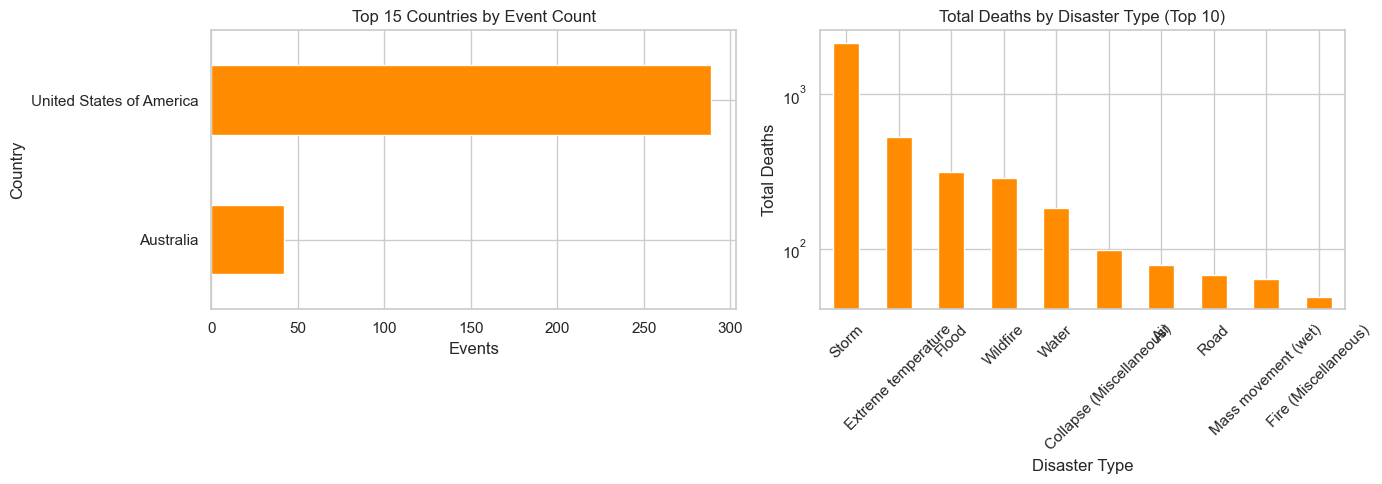

In [24]:
# Top 15 countries by event count
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

emdat["Country"].value_counts().head(15).plot(
    kind="barh", ax=axes[0], color="darkorange"
)
axes[0].set_title("Top 15 Countries by Event Count")
axes[0].set_xlabel("Events")
axes[0].invert_yaxis()

# Deaths by disaster type (sum, log scale)
deaths_by_type = (
    emdat.groupby("Disaster Type")["Total Deaths"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
deaths_by_type.plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Total Deaths by Disaster Type (Top 10)")
axes[1].set_ylabel("Total Deaths")
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()